# DC Housing Market Analysis: Modeling

## Introduction

This notebook builds upon the exploratory data analysis performed in previous notebooks to develop predictive models for DC housing prices. We'll implement and evaluate multiple modeling approaches, from traditional time series methods to advanced machine learning techniques, to identify the most important variables and other key insights related to the DC housing market.

Our goal is to:
1. Implement various modeling approaches for housing price prediction
2. Compare model performance to identify the most effective techniques
3. Analyze key drivers of housing price changes
4. Provide actionable insights based on our findings

Let's begin by importing the necessary libraries and setting up our environment.

In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Statistical and modeling libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# Set visualization styling for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directory for saving outputs
output_dir = 'outputs/models_and_forecasts_final'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory set to: {output_dir}")

Output directory set to: outputs/models_and_forecasts_final


## 1. Data Loading and Preparation

First, we need to load the feature-engineered dataset created in the previous notebook. This dataset contains a wide range of economic indicators and derived features that will serve as the foundation for our models.

The dataset includes:
- Primary economic indicators (CPI, unemployment rate, interest rates, etc.)
- Housing market metrics (Zillow Home Value Index, mortgage rates)
- Demographic data (population, household income)
- Derived features (lagged variables, moving averages, growth rates)
- Interaction terms and affordability metrics

In [28]:
# Load the feature-engineered dataset
df = pd.read_csv('dc_economic_monthly_engineered_features_clean.csv')

# Convert Date column to datetime and set as index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")

# Display the first few rows
df.head()

Dataset dimensions: 282 rows × 142 columns
Time period: January 2001 to June 2024
Duration: 23.4 years


,Year,Month,Unemployment_Rate,CPI,Interest_Rate,Mortgage_Rate,ZHVI,GDP_Growth,Median_Household_Income,Population,Poverty_Rate,Marriage_Rate,Divorce_Rate,Unemployment_Rate_lag1,Unemployment_Rate_lag3,Unemployment_Rate_lag6,Unemployment_Rate_lag12,CPI_lag1,CPI_lag3,CPI_lag6,CPI_lag12,Interest_Rate_lag1,Interest_Rate_lag3,Interest_Rate_lag6,Interest_Rate_lag12,Mortgage_Rate_lag1,Mortgage_Rate_lag3,Mortgage_Rate_lag6,Mortgage_Rate_lag12,ZHVI_lag1,ZHVI_lag3,ZHVI_lag6,ZHVI_lag12,GDP_Growth_lag1,GDP_Growth_lag3,GDP_Growth_lag6,GDP_Growth_lag12,Median_Household_Income_lag1,Median_Household_Income_lag3,Median_Household_Income_lag6,Median_Household_Income_lag12,Population_lag1,Population_lag3,Population_lag6,Population_lag12,Poverty_Rate_lag1,Poverty_Rate_lag3,Poverty_Rate_lag6,Poverty_Rate_lag12,Marriage_Rate_lag1,Marriage_Rate_lag3,Marriage_Rate_lag6,Marriage_Rate_lag12,Divorce_Rate_lag1,Divorce_Rate_lag3,Divorce_Rate_lag6,Divorce_Rate_lag12,Unemployment_Rate_ma3,Unemployment_Rate_ma6,Unemployment_Rate_ma12,CPI_ma3,CPI_ma6,CPI_ma12,Interest_Rate_ma3,Interest_Rate_ma6,Interest_Rate_ma12,Mortgage_Rate_ma3,Mortgage_Rate_ma6,Mortgage_Rate_ma12,ZHVI_ma3,ZHVI_ma6,ZHVI_ma12,GDP_Growth_ma3,GDP_Growth_ma6,GDP_Growth_ma12,Median_Household_Income_ma3,Median_Household_Income_ma6,Median_Household_Income_ma12,Population_ma3,Population_ma6,Population_ma12,Poverty_Rate_ma3,Poverty_Rate_ma6,Poverty_Rate_ma12,Marriage_Rate_ma3,Marriage_Rate_ma6,Marriage_Rate_ma12,Divorce_Rate_ma3,Divorce_Rate_ma6,Divorce_Rate_ma12,Unemployment_Rate_mom_pct,Unemployment_Rate_yoy_pct,Unemployment_Rate_3m_pct,CPI_mom_pct,CPI_yoy_pct,CPI_3m_pct,Interest_Rate_mom_pct,Interest_Rate_yoy_pct,Interest_Rate_3m_pct,Mortgage_Rate_mom_pct,Mortgage_Rate_yoy_pct,Mortgage_Rate_3m_pct,ZHVI_mom_pct,ZHVI_yoy_pct,ZHVI_3m_pct,GDP_Growth_mom_pct,GDP_Growth_yoy_pct,GDP_Growth_3m_pct,Median_Household_Income_mom_pct,Median_Household_Income_yoy_pct,Median_Household_Income_3m_pct,Population_mom_pct,Population_yoy_pct,Population_3m_pct,Poverty_Rate_mom_pct,Poverty_Rate_yoy_pct,Poverty_Rate_3m_pct,Marriage_Rate_mom_pct,Marriage_Rate_yoy_pct,Marriage_Rate_3m_pct,Divorce_Rate_mom_pct,Divorce_Rate_yoy_pct,Divorce_Rate_3m_pct,interest_unemployment,mortgage_income,cpi_unemployment,price_to_income,monthly_payment,payment_to_income,real_mortgage_rate,month_sin,month_cos,winter,spring,summer,fall,zhvi_trend,zhvi_seasonal,zhvi_residual,zhvi_diff1,cpi_diff1,mortgage_rate_diff1
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2001,1,5.90,175.90,5.98,7.03,193160.24,-0.44,41170.00,574.50,18.10,4.96,3.04,5.90,5.70,5.60,5.70,175.60,175.15,174.80,169.80,6.40,6.51,6.54,5.45,7.38,7.79,8.15,8.21,191629.48,188359.20,183644.45,179200.93,1.32,1.84,2.11,1.50,41523.01,42129.74,42654.93,41220.00,572.05,572.05,572.05,572.05,17.50,17.50,17.50,17.50,3.92,4.41,6.86,3.92,3.20,3.36,3.20,3.36,5.87,5.78,5.71,175.60,175.31,174.20,6.30,6.40,6.28,7.39,7.65,7.96,191568.45,189170.56,185105.05,1.09,1.04,3.14,41510.90,41928.57,42158.21,572.87,572.46,572.25,17.70,17.60,17.55,4.27,4.67,4.99,3.15,3.23,3.17,0.00,3.51,3.51,0.17,3.59,0.43,-6.56,9.72,-8.14,-4.73,-14.34,-9.78,0.80,7.79,2.55,-133.35,-129.43,-123.95,-0.85,-0.12,-2.28,0.43,0.43,0.43,3.43,3.43,3.43,26.53,26.53,12.47,-4.84,-9.38,-9.38,35.28,289528.03,1037.81,4.69,1031.45,30.06,3.44,0.50,0.87,1,0,0,0,193228.26,-801.23,733.22,1530.76,0.30,-0.35
2001-02-01,2001,2,6.00,176.55,5.49,7.05,194520.99,-1.30,40802.35,574.50,18.10,4.96,2.90,5.90,5.80,5.70,5.70,175.90,175.30,174.90,171.50,5.98,6.51,6.50,5.73,7.03,7.75,8.03,8.32,193160.24,189915.62,185187.09,179346.63,-0.44,2.40,0.40,1.50,41170.00,41839.68,42545.43,41771.03,574.50,572.05,572.05,572.05,18.10,17.50,17.50,17.50,4.96,3.92,5.88,3.92,3.04,3.20,3.20,3.20,5.93,5.83,5.73,176.02,175.58,174.62,5.96,6.23,6.26,7.15,7.49,7.86,193103.57,190726.21,186369.58,-0.14,0.75,2.91,41165.12,41638.06,42077.48,573.68,572.87,572.46,17.90,17.70,17.60,

### 1.1 Time-based Train-Test Split

For forecasting tasks, we need to be careful with how we split our data. Unlike traditional machine learning where we might use random sampling, time series forecasting requires maintaining the temporal order of observations.

We'll use a time-based split, where:
- Training data: Earlier portion of the time series (80%)
- Test data: Most recent portion of the time series (20%)

This approach simulates a real-world forecasting scenario where we use historical data to predict future values.

In [29]:
# Split the data into training and test sets (80% train, 20% test)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Training set: {train_df.shape[0]} observations from {train_df.index.min().strftime('%B %Y')} to {train_df.index.max().strftime('%B %Y')}")
print(f"Test set: {test_df.shape[0]} observations from {test_df.index.min().strftime('%B %Y')} to {test_df.index.max().strftime('%B %Y')}")

# Create a copy of the original ZHVI series for reference
zhvi_series = df['ZHVI'].copy()

Training set: 225 observations from January 2001 to September 2019
Test set: 57 observations from October 2019 to June 2024


### 1.2 Feature and Target Selection

Now we need to prepare our feature set for machine learning models. We'll need to be careful to avoid data leakage by excluding:

1. **Target-derived features**: Components directly derived from our target variable (ZHVI) like its lags, moving averages, or decomposition
2. **Future information**: Any features that would not be available at prediction time
3. **Non-feature columns**: Metadata columns like Year and Month (though we preserve the Date index for time series analysis)

Additionally, we'll standardize our features (mean=0, std=1) to ensure all variables are on a comparable scale, which is important for many machine learning algorithms.

In [30]:
# Select only key fundamental features based on housing market theory
# Instead of using all features, we'll use a carefully selected subset
feature_cols = [
    # Core economic indicators
    'CPI', 'Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'GDP_Growth', 
    'Median_Household_Income', 'Population', 'Poverty_Rate',
    
    # Key lagged variables (1 and 12 months)
    'CPI_lag12', 'Unemployment_Rate_lag12', 'Interest_Rate_lag12', 'Mortgage_Rate_lag12',
    
    # Affordability metrics 
    'price_to_income', 'monthly_payment', 'payment_to_income',
    
    # Seasonality
    'month_sin', 'month_cos',
    
    # 1-month changes
    'CPI_mom_pct', 'Mortgage_Rate_mom_pct', 'Unemployment_Rate_mom_pct'
]

# Split data into features (X) and target (y)
X_train = train_df[feature_cols]
y_train = train_df['ZHVI']  # Target variable: housing prices
X_test = test_df[feature_cols]
y_test = test_df['ZHVI']

print(f"Number of selected features: {len(feature_cols)}")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Number of selected features: 20
Training features shape: (225, 20)
Test features shape: (57, 20)


In [31]:
# Standardize features for ML models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Save the scaler for future use
with open(f'{output_dir}/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### 1.3 Model Evaluation Function

Before building models, let's define a comprehensive evaluation function that will:
1. Calculate key regression metrics (RMSE, MAE, R², MAPE)
2. Visualize actual vs. predicted values 
3. Analyze residuals to check for patterns or issues
4. Save high-quality visualizations and metrics

This will ensure consistent evaluation across all models and provide detailed insights into model performance.

In [32]:
def evaluate_model(y_true, y_pred, model_name='Model', plot=True):
    """Comprehensive model evaluation function
    
    Parameters:
    -----------
    y_true : array-like
        Actual target values
    y_pred : array-like
        Predicted target values
    model_name : str
        Name of the model for reporting
    plot : bool
        Whether to create visualization plots
        
    Returns:
    --------
    dict
        Dictionary with performance metrics
    """
    # Ensure inputs are properly aligned
    if isinstance(y_true, pd.Series) and isinstance(y_pred, pd.Series):
        y_true, y_pred = y_true.align(y_pred, join='inner')
    elif not isinstance(y_pred, pd.Series) and isinstance(y_true, pd.Series):
        y_pred = pd.Series(y_pred, index=y_true.index)
    
    # Calculate error metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate MAPE (avoiding division by zero)
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100 if sum(mask) > 0 else np.nan
    
    # Calculate directional accuracy (how often the model correctly predicts the direction of change)
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    direction_match = np.sign(y_true_diff) == np.sign(y_pred_diff)
    directional_accuracy = np.mean(direction_match) * 100  # Convert to percentage
    
    # Print evaluation metrics
    print(f"\n===== {model_name} Performance =====")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    if not np.isnan(mape):
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Directional Accuracy: {directional_accuracy:.2f}%")
    
    # Create visualizations
    if plot:
        # Plot actual vs predicted values
        plt.figure(figsize=(14, 8))
        plt.plot(y_true.index, y_true, label='Actual', linewidth=2.5, color='#1f77b4')
        plt.plot(y_pred.index, y_pred, label='Predicted', linewidth=2.5, color='#d62728')
        plt.title(f'{model_name}: Housing Price Predictions', fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Housing Price (ZHVI, $)')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Add shading for test period
        min_test_date = y_test.index.min()
        plt.axvspan(min_test_date, y_test.index.max(), alpha=0.1, color='gray')
        plt.axvline(x=min_test_date, color='gray', linestyle='--', alpha=0.8)
        plt.text(min_test_date, y_true.max()*0.9, 'Test Set', 
                 fontsize=12, ha='right', rotation=90, va='top')
        
        # Format y-axis with dollar signs
        plt.gca().yaxis.set_major_formatter('${x:,.0f}')
        
        # Add annotations with key metrics
        plt.annotate(f'RMSE: ${rmse:,.0f}', xy=(0.02, 0.95), xycoords='axes fraction', 
                     fontsize=12, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))
        plt.annotate(f'R²: {r2:.4f}', xy=(0.02, 0.89), xycoords='axes fraction', 
                     fontsize=12, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{model_name.replace(" ", "_").lower()}_predictions.png')
        plt.show()
        
        # Plot residuals
        residuals = y_true - y_pred
        
        plt.figure(figsize=(14, 10))
        
        # Residual time series
        plt.subplot(2, 1, 1)
        plt.plot(residuals.index, residuals, color='#2ca02c', linewidth=2)
        plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
        plt.title(f'{model_name}: Residuals Over Time', fontweight='bold')
        plt.ylabel('Residual ($)')
        plt.grid(True, alpha=0.3)
        
        # Add shading for test period
        plt.axvspan(min_test_date, y_test.index.max(), alpha=0.1, color='gray')
        
        # Residual histogram
        plt.subplot(2, 1, 2)
        sns.histplot(residuals, kde=True, color='#2ca02c', alpha=0.7, bins=30)
        plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
        plt.title('Residual Distribution', fontweight='bold')
        plt.xlabel('Residual ($)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{model_name.replace(" ", "_").lower()}_residuals.png')
        plt.show()
    
    # Return metrics as a dictionary
    return {
        'model_name': model_name,
        'rmse': float(rmse),
        'mae': float(mae),
        'mape': float(mape) if not np.isnan(mape) else None,
        'r2': float(r2),
        'directional_accuracy': float(directional_accuracy)
    }

## 2. Time Series Models

We'll start with traditional time series models, which are specifically designed to capture temporal patterns in data. These models focus on using past values and patterns to predict future values.

### 2.1 ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a classical time series model that combines:
- **AR**: AutoRegressive component - uses past values to predict future values
- **I**: Integrated component - differencing to make the series stationary 
- **MA**: Moving Average component - uses past forecast errors

Based on our EDA, we'll try an ARIMA(1,1,1) model, which means:
- p=1: One lag of the stationarized series in the forecasting equation
- d=1: First-differencing to achieve stationarity
- q=1: One lag of the forecast error in the prediction equation

In [33]:
# Define a function to fit and evaluate ARIMA-type models
def fit_arima_model(train_data, test_data, order, seasonal_order=None, exog_train=None, exog_test=None):
    """Fit an ARIMA or SARIMA model and evaluate performance"""
    try:
        # Determine model type
        if seasonal_order:
            # SARIMA model (includes seasonal component)
            model = SARIMAX(
                train_data,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_name = f"SARIMA{order}{seasonal_order}"
        else:
            # ARIMA model (non-seasonal)
            model = ARIMA(train_data, exog=exog_train, order=order)
            model_name = f"ARIMA{order}"
        
        # Add exogenous variables to model name if used
        if exog_train is not None:
            if isinstance(exog_train, pd.DataFrame):
                model_name += f" with {len(exog_train.columns)} exogenous variables"
            else:
                model_name += " with exogenous variables"
        
        print(f"\nFitting {model_name}...")
        
        # Fit the model
        fitted_model = model.fit() # Suppress convergence messages
        
        # Generate predictions
        if exog_test is not None:
            # If using exogenous variables, include them in forecast
            test_pred = fitted_model.forecast(steps=len(test_data), exog=exog_test)
        else:
            # Simple forecast without exogenous variables
            test_pred = fitted_model.forecast(steps=len(test_data))
        
        # Convert predictions to Series with the same index as test data
        if isinstance(test_data, pd.Series):
            test_pred = pd.Series(test_pred, index=test_data.index)
        
        # Evaluate model performance
        metrics = evaluate_model(test_data, test_pred, model_name=model_name)
        
        # Save the model
        with open(f'{output_dir}/{model_name.replace(" ", "_").lower()}.pkl', 'wb') as f:
            pickle.dump(fitted_model, f)
        
        return fitted_model, test_pred, metrics
    
    except Exception as e:
        print(f"Error fitting {model_name if 'model_name' in locals() else 'ARIMA model'}: {e}")
        return None, None, None


Fitting ARIMA(1, 1, 1)...

===== ARIMA(1, 1, 1) Performance =====
Root Mean Squared Error (RMSE): $81994.42
Mean Absolute Error (MAE): $71682.68
Mean Absolute Percentage Error (MAPE): 13.67%
R-squared (R²): -2.7549
Directional Accuracy: 82.14%


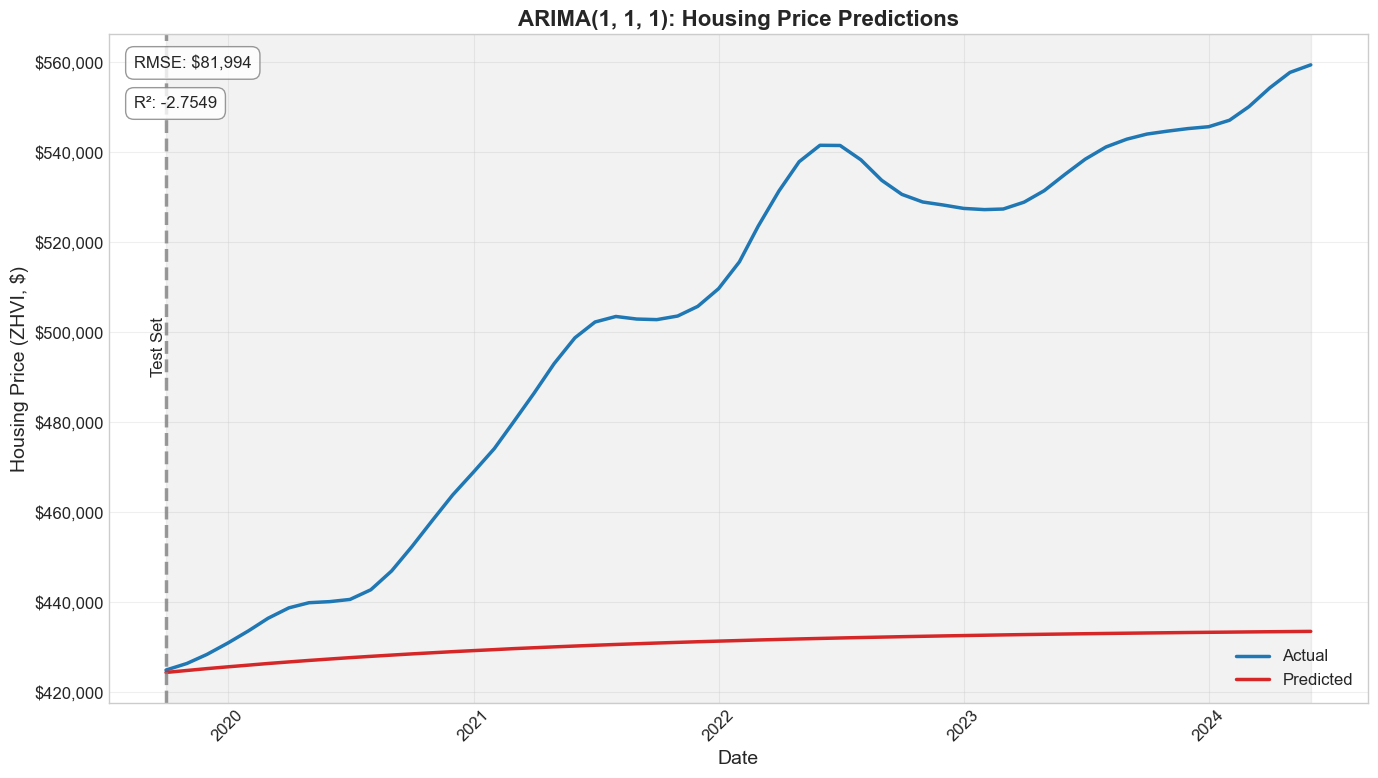

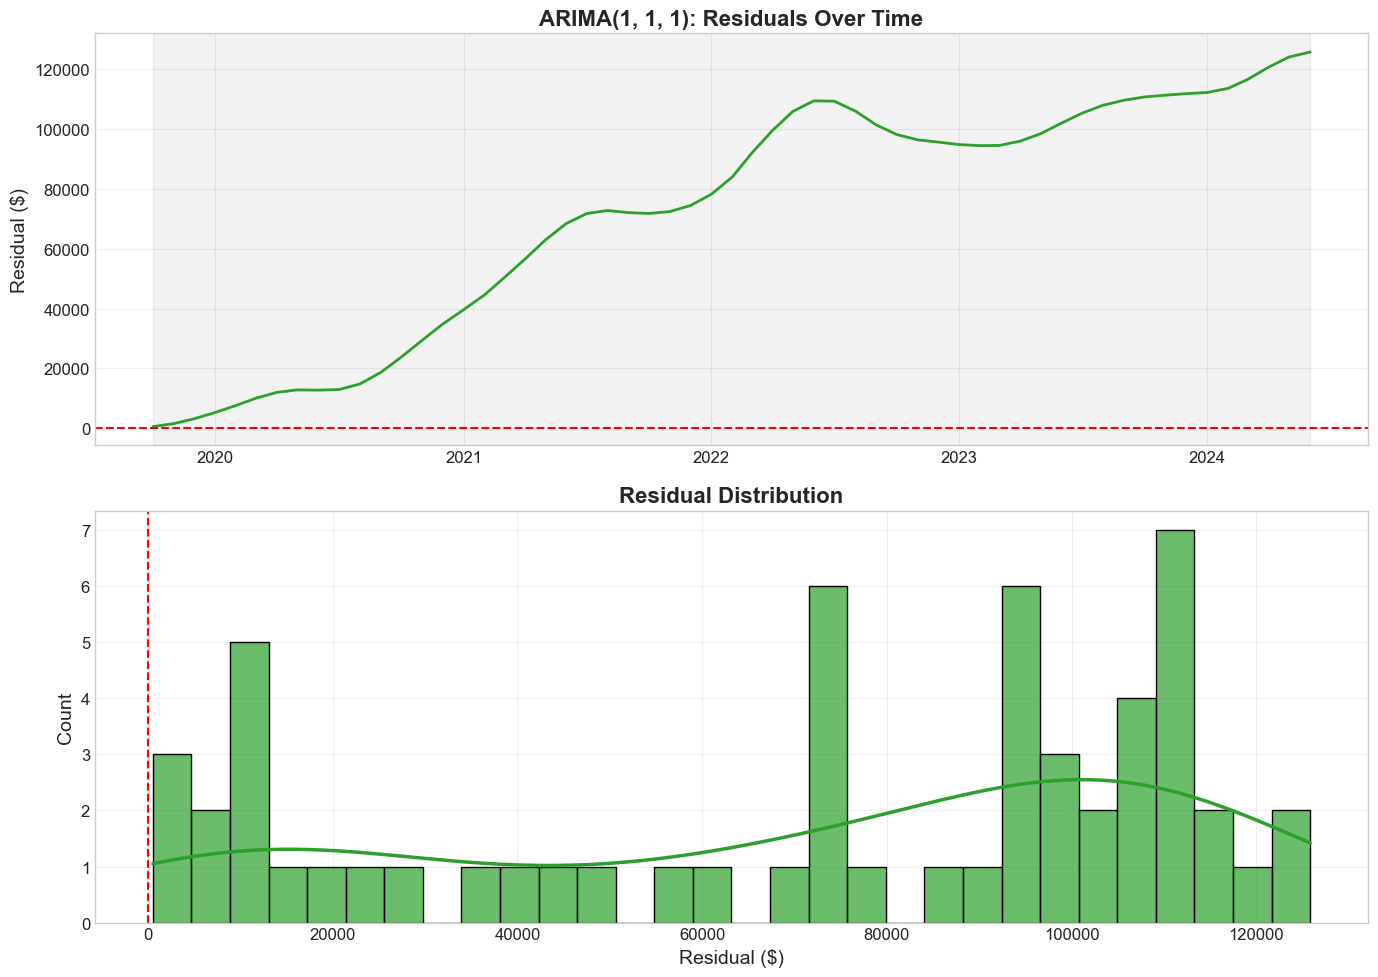


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   ZHVI   No. Observations:                  225
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2037.401
Date:                Tue, 25 Mar 2025   AIC                           4080.802
Time:                        15:07:53   BIC                           4091.037
Sample:                    01-01-2001   HQIC                          4084.933
                         - 09-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9564      0.008    114.281      0.000       0.940       0.973
ma.L1         -0.9229      0.011    -87.859      0.000      -0.943      -0.902
sigma2      4.379e+06   5.35e-

In [34]:
# Fit ARIMA(1,1,1) model to the ZHVI series
arima_model, arima_pred, arima_metrics = fit_arima_model(
    train_df['ZHVI'],  # Training data (target variable only) 
    test_df['ZHVI'],   # Test data (for evaluation)
    order=(1, 1, 1)    # (p, d, q) parameters
)

# Display model summary
if arima_model:
    print("\nARIMA Model Summary:")
    print(arima_model.summary())

### 2.2 SARIMA Model

SARIMA (Seasonal ARIMA) extends the ARIMA model to capture seasonal patterns. It adds seasonal components:
- **P**: Seasonal autoregressive order
- **D**: Seasonal differencing order
- **Q**: Seasonal moving average order
- **S**: Seasonal period (12 for monthly data)

Our EDA revealed seasonal patterns in housing prices with peaks in summer months, so we'll implement a SARIMA model to capture this seasonality.


Fitting SARIMA(1, 1, 1)(1, 0, 1, 12)...

===== SARIMA(1, 1, 1)(1, 0, 1, 12) Performance =====
Root Mean Squared Error (RMSE): $78016.14
Mean Absolute Error (MAE): $68215.22
Mean Absolute Percentage Error (MAPE): 13.01%
R-squared (R²): -2.3994
Directional Accuracy: 82.14%


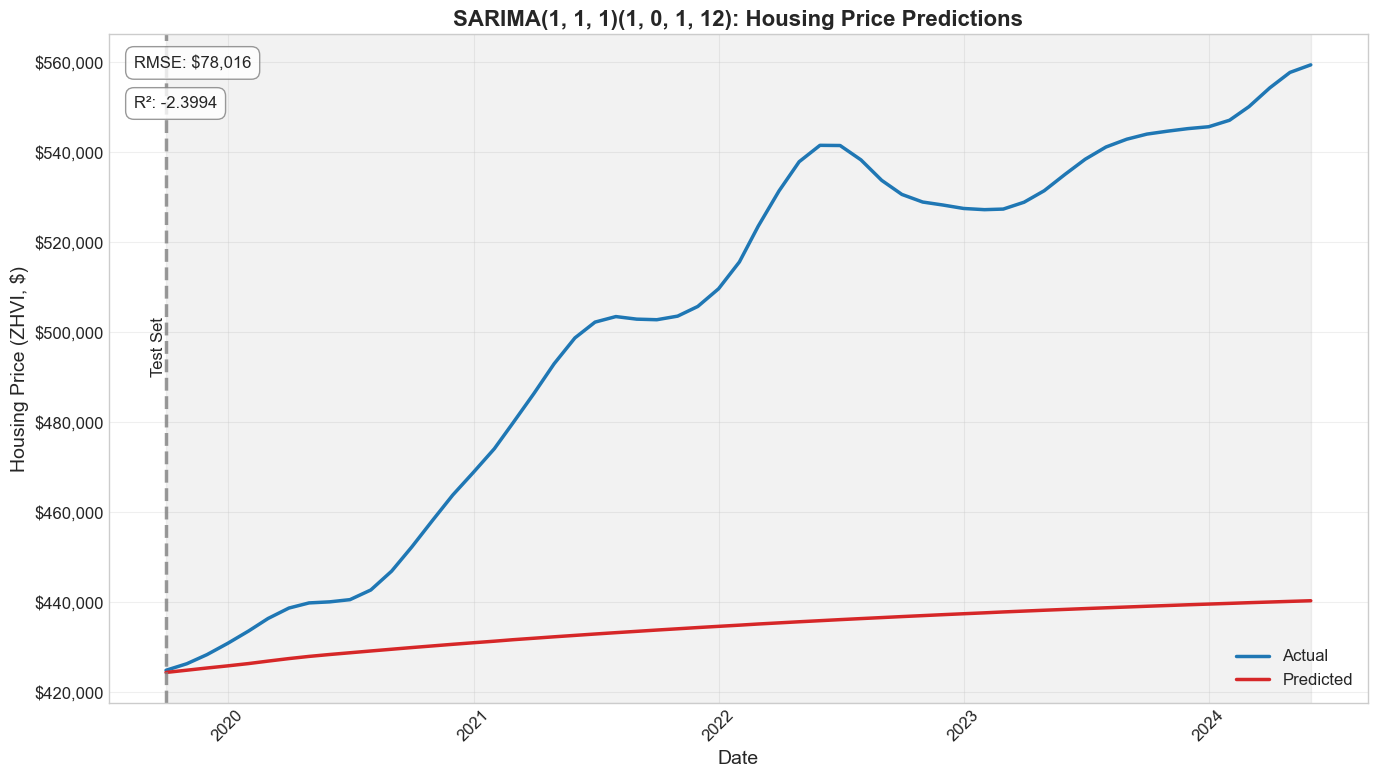

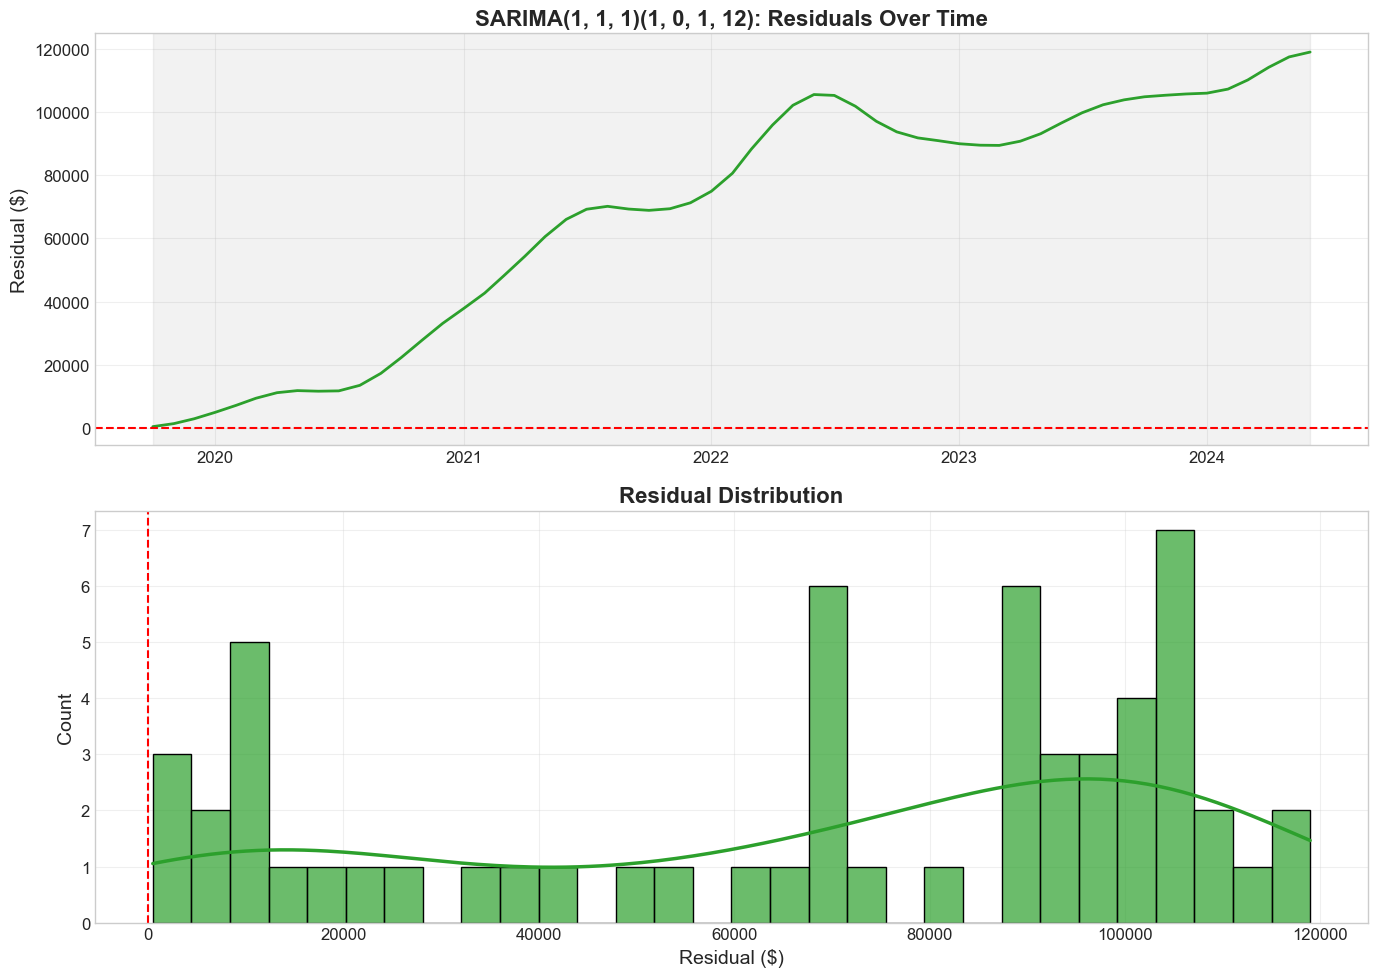


SARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                               ZHVI   No. Observations:                  225
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1550.597
Date:                            Tue, 25 Mar 2025   AIC                           3111.193
Time:                                    15:08:20   BIC                           3127.929
Sample:                                01-01-2001   HQIC                          3117.959
                                     - 09-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9782      0.014     71.942      0.000       0.952       1.005
ma.L1       

In [35]:
# Fit SARIMA model with seasonal component (period=12 for monthly data)
sarima_model, sarima_pred, sarima_metrics = fit_arima_model(
    train_df['ZHVI'],  # Training data (target variable only)
    test_df['ZHVI'],   # Test data (for evaluation)
    order=(1, 1, 1),   # (p, d, q) parameters
    seasonal_order=(1, 0, 1, 12)  # (P, D, Q, S) seasonal parameters
)

# Display model summary
if sarima_model:
    print("\nSARIMA Model Summary:")
    print(sarima_model.summary())

### 2.3 ARIMAX Model (ARIMA with Exogenous Variables)

ARIMAX extends ARIMA by incorporating external (exogenous) variables that may influence the target variable. This allows us to incorporate economic indicators like interest rates, unemployment, and income levels into our forecast.

Based on our correlation analysis, we'll select key economic indicators that showed strong relationships with housing prices.


Fitting ARIMA(1, 1, 1) with 4 exogenous variables...

===== ARIMA(1, 1, 1) with 4 exogenous variables Performance =====
Root Mean Squared Error (RMSE): $32999.92
Mean Absolute Error (MAE): $29386.43
Mean Absolute Percentage Error (MAPE): 5.83%
R-squared (R²): 0.3918
Directional Accuracy: 66.07%


/home/vboxuser/25-spring-rding/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


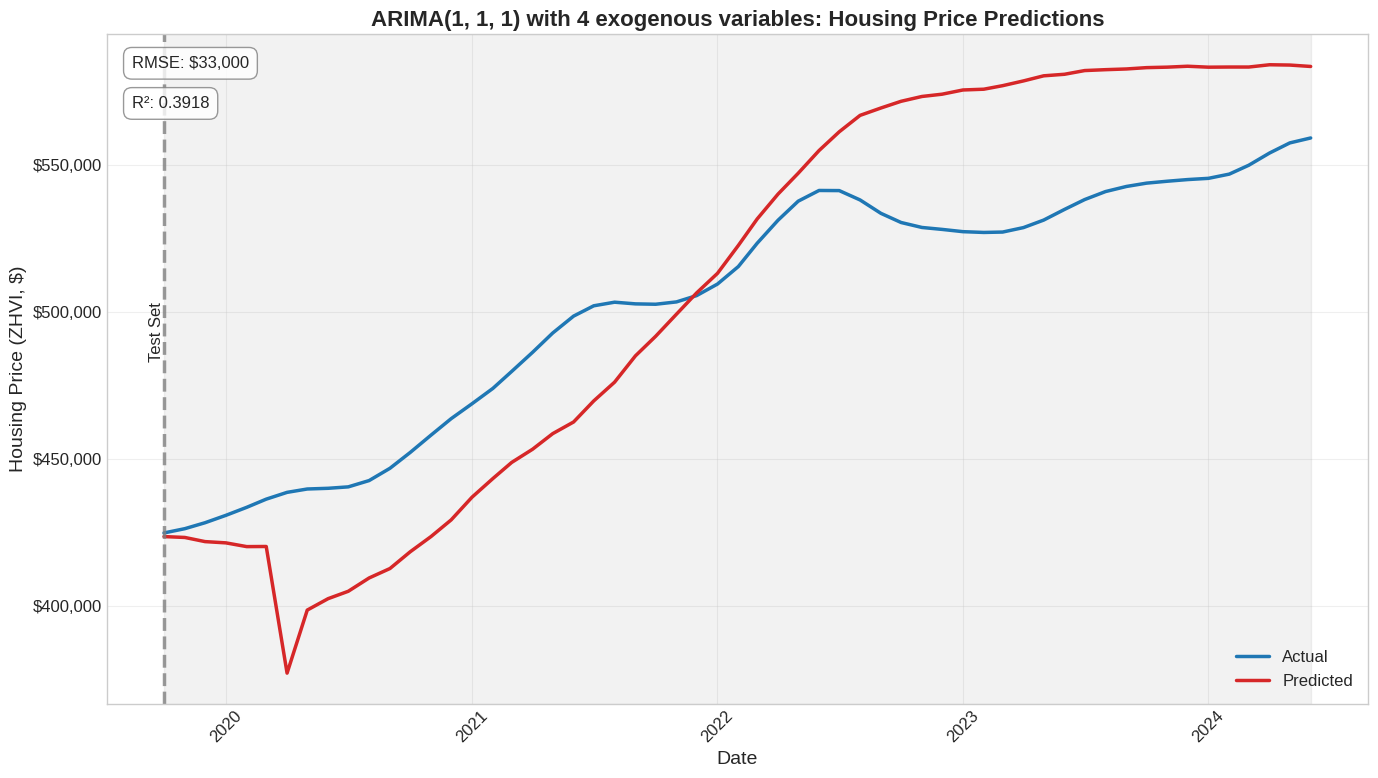

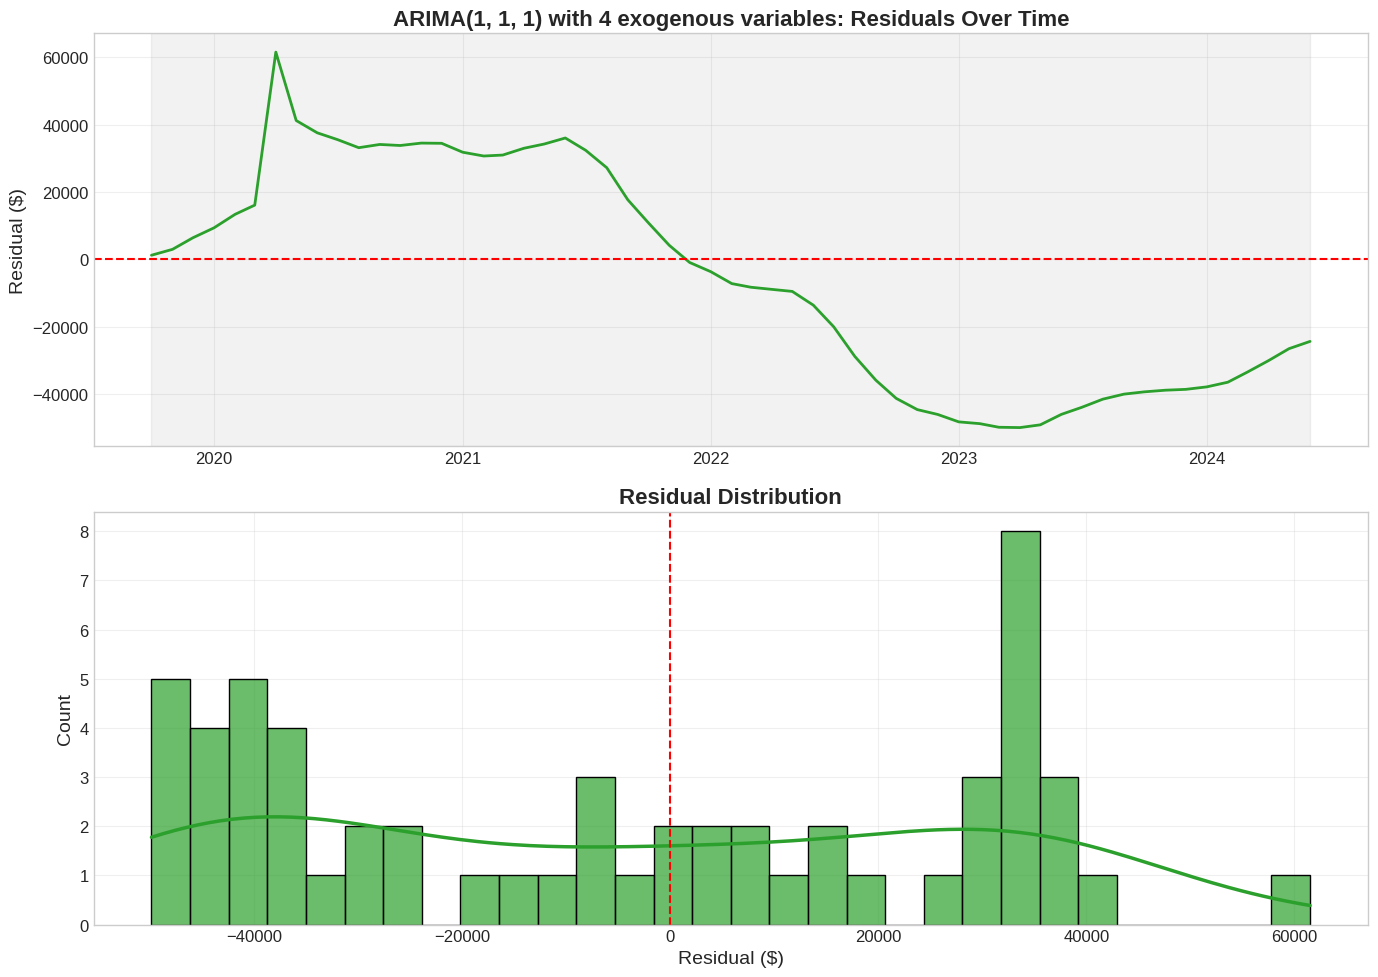


ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   ZHVI   No. Observations:                  225
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1833.725
Date:                Sat, 08 Mar 2025   AIC                           3681.450
Time:                        19:44:53   BIC                           3705.331
Sample:                    01-01-2001   HQIC                          3691.090
                         - 09-01-2019                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Mortgage_Rate             454.2493    324.232      1.401      0.161    -181.234    1089.733
CPI                       302.7992     69.836      4.336      0.000  

In [ ]:
# Select key economic indicators as exogenous variables
exog_vars = ['Mortgage_Rate', 'CPI', 'Unemployment_Rate', 'Median_Household_Income']

# Fit ARIMAX model with exogenous variables
arimax_model, arimax_pred, arimax_metrics = fit_arima_model(
    train_df['ZHVI'],          # Training data (target variable)
    test_df['ZHVI'],           # Test data (for evaluation)
    order=(1, 1, 1),           # (p, d, q) parameters
    exog_train=train_df[exog_vars],  # Exogenous variables for training
    exog_test=test_df[exog_vars]     # Exogenous variables for testing
)

# Display model summary
if arimax_model:
    print("\nARIMAX Model Summary:")
    print(arimax_model.summary())

## 3. Machine Learning Models

Now, let's implement machine learning models that can capture complex, potentially non-linear relationships between our features and target variable. Unlike time series models that focus primarily on temporal patterns, these models can leverage the full range of economic indicators and derived features.

We'll start with simpler models and progressively move to more complex ones.

### 3.1 Linear Regression Models

Linear regression models are interpretable and provide a good baseline for more complex approaches. They model the target variable as a linear combination of features.


Fitting Linear Regression with reduced features...

===== Linear Regression (Reduced Features) Performance =====
Root Mean Squared Error (RMSE): $29721.13
Mean Absolute Error (MAE): $26688.55
Mean Absolute Percentage Error (MAPE): 5.31%
R-squared (R²): 0.5066
Directional Accuracy: 69.64%


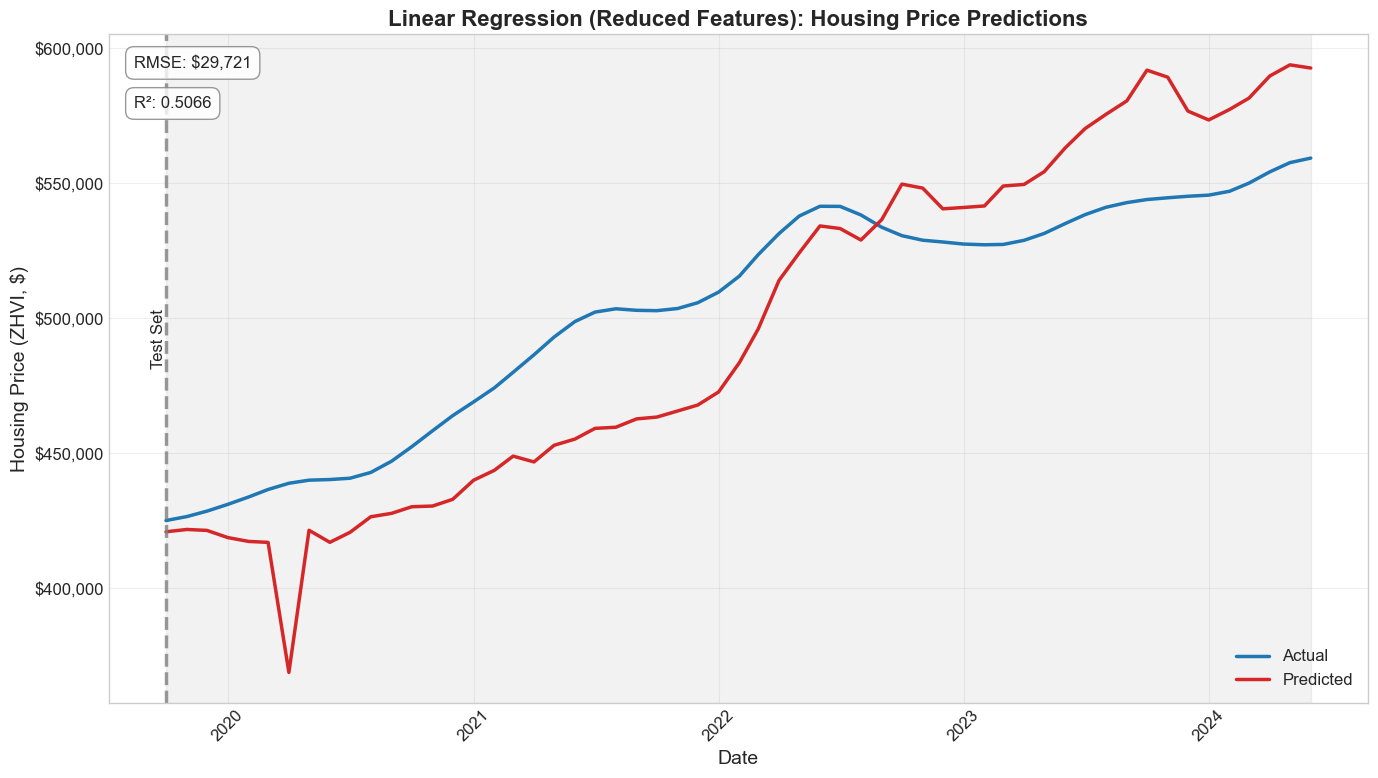

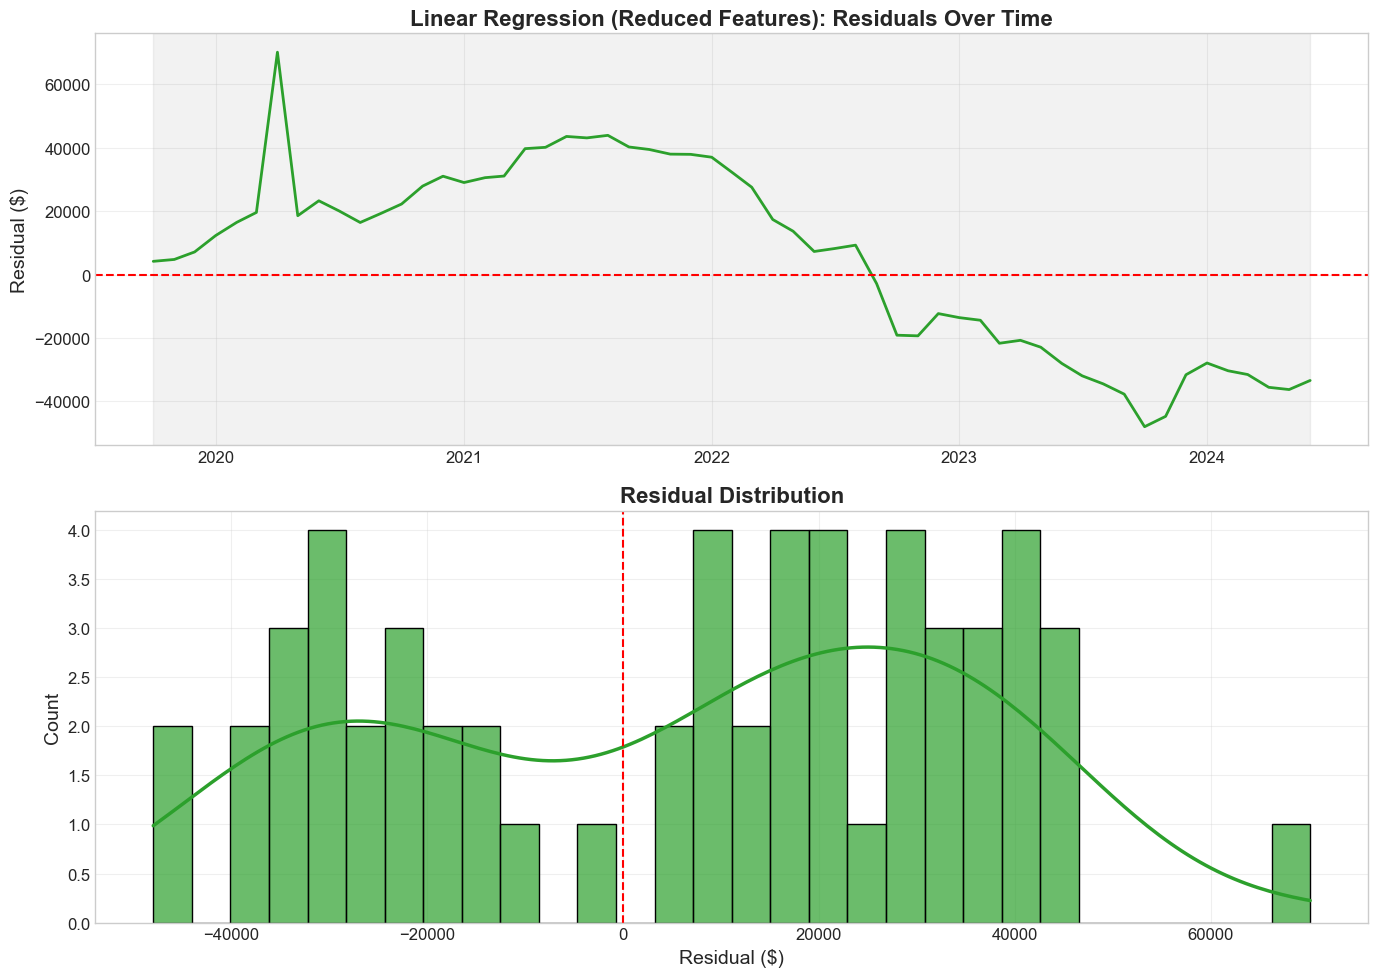

In [36]:
# Linear Regression with reduced features
print("\nFitting Linear Regression with reduced features...")
lr_reduced = LinearRegression()
lr_reduced.fit(X_train_scaled, y_train)
lr_reduced_pred = lr_reduced.predict(X_test_scaled)
lr_reduced_metrics = evaluate_model(y_test, lr_reduced_pred, model_name='Linear Regression (Reduced Features)')

# Save the model
with open(f'{output_dir}/linear_regression_reduced_model.pkl', 'wb') as f:
    pickle.dump(lr_reduced, f)